In [14]:
import pandas as pd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import adfuller

df = pd.read_csv("../data/time_series_country.csv")
df.head()
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3056 entries, 0 to 3055
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Country         3056 non-null   str    
 1   Subregion       3056 non-null   str    
 2   Year            3056 non-null   int64  
 3   Country Code    3056 non-null   str    
 4   Total_Deaths    3056 non-null   float64
 5   Region          3056 non-null   str    
 6   Population      3056 non-null   float64
 7   Mortality_Rate  3056 non-null   float64
dtypes: float64(3), int64(1), str(4)
memory usage: 191.1 KB


# 4.1 Global Analysis

In [16]:
# 4.1 Global Series
global_ts = (
    df.groupby("Year")["Mortality_Rate"]
    .mean()
    .sort_index()
)

# Rolling Statistics
rolling_mean = global_ts.rolling(window=5).mean()
rolling_std = global_ts.rolling(window=5).std()

In [17]:
# ADF Test -> Summary Table
alpha = 0.05

# First Difference
diff_ts = global_ts.diff().dropna()

def safe_adf(ts):
    ts = ts.dropna()
    # tránh lỗi: quá ít điểm hoặc chuỗi hằng
    if len(ts) < 4 or np.isclose(ts.max(), ts.min()):
        return (np.nan, np.nan, "Không đủ dữ liệu")
    try:
        res = adfuller(ts)
        stat, pval = res[0], res[1]
        conclusion = "Dừng" if pval < alpha else "Không dừng"
        return (stat, pval, conclusion)
    except Exception:
        return (np.nan, np.nan, "Không đủ dữ liệu")

stat0, p0, concl0 = safe_adf(global_ts)
stat1, p1, concl1 = safe_adf(diff_ts)

adf_table = pd.DataFrame(
    [
        ["Original", stat0, p0, len(global_ts), concl0],
        ["Differenced (1st)", stat1, p1, len(diff_ts), concl1],
    ],
    columns=["Series", "ADF Statistic", "p-value", "NumYears", "Conclusion"]
)

adf_table["p-value"] = adf_table["p-value"].map(lambda x: f"{x:.6f}" if pd.notna(x) else x)
adf_table

,Series,ADF Statistic,p-value,NumYears,Conclusion
0,Original,-4.903379,0.000034,25,Dừng
1,Differenced (1st),-3.364405,0.012234,24,Dừng


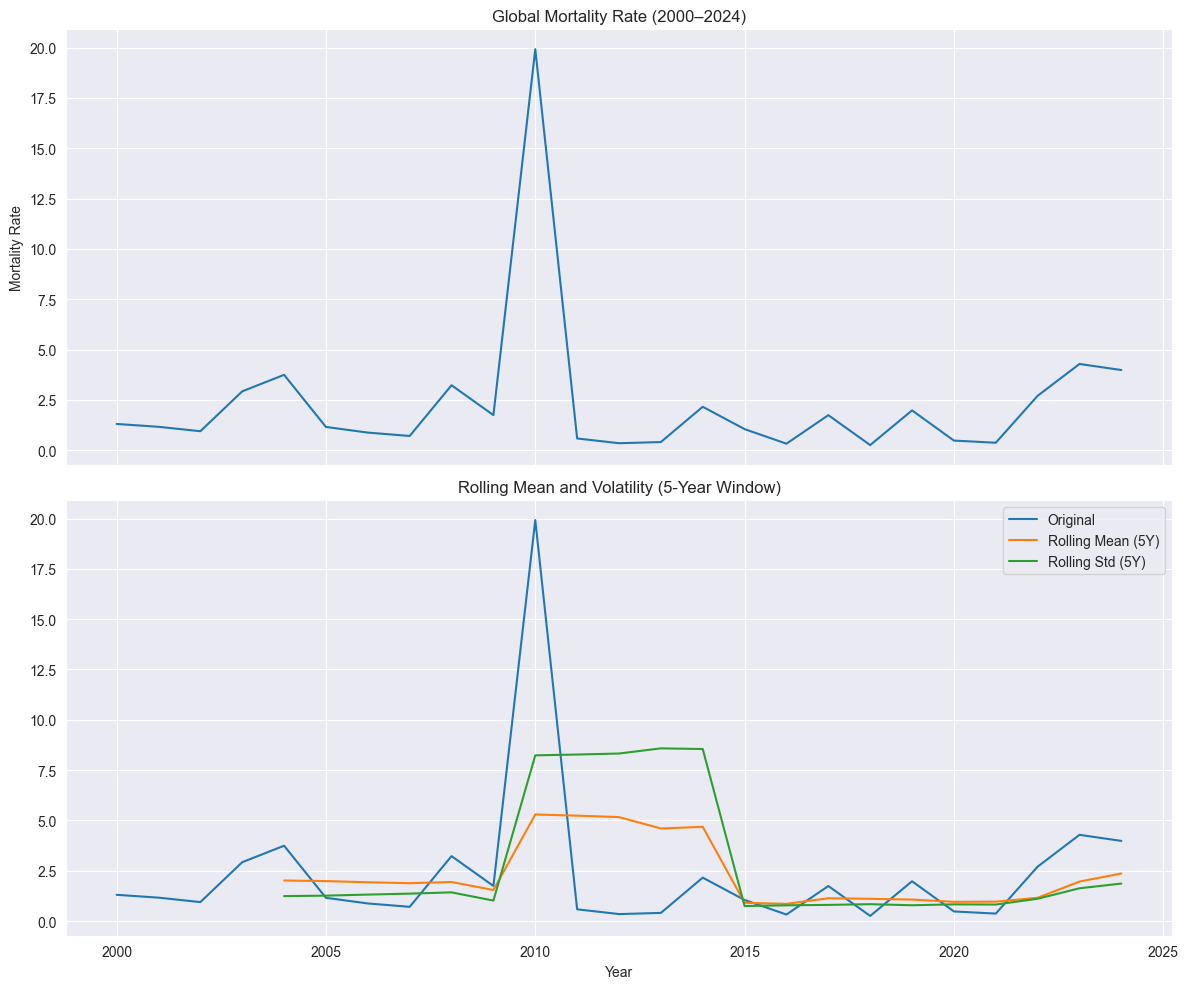

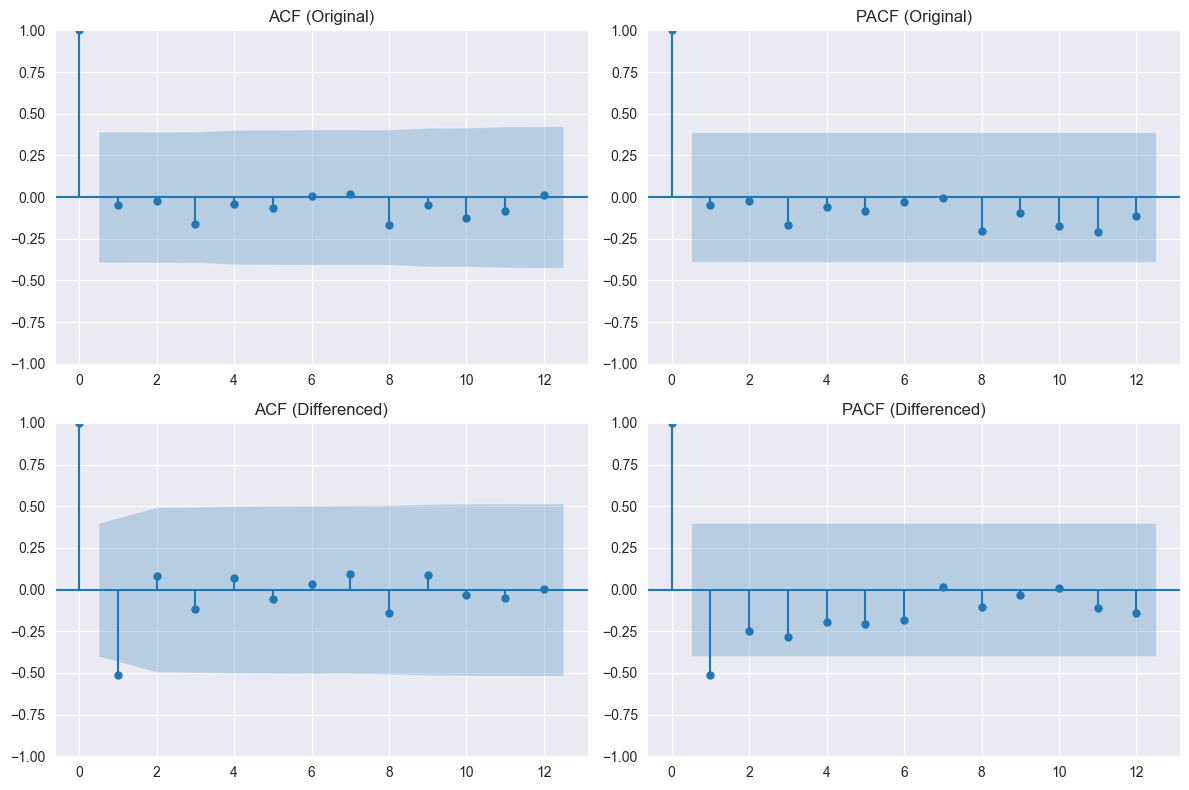

In [18]:

# Figure 1: Trend + Rolling

fig, axes = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

# Trend
axes[0].plot(global_ts)
axes[0].set_title("Global Mortality Rate (2000–2024)")
axes[0].set_ylabel("Mortality Rate")

# Rolling Mean + Std
axes[1].plot(global_ts, label="Original")
axes[1].plot(rolling_mean, label="Rolling Mean (5Y)")
axes[1].plot(rolling_std, label="Rolling Std (5Y)")
axes[1].legend()
axes[1].set_title("Rolling Mean and Volatility (5-Year Window)")
axes[1].set_xlabel("Year")

plt.tight_layout()
plt.show()

# Figure 2: ACF & PACF

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

plot_acf(global_ts, ax=axes[0, 0])
axes[0, 0].set_title("ACF (Original)")

plot_pacf(global_ts, ax=axes[0, 1])
axes[0, 1].set_title("PACF (Original)")

plot_acf(diff_ts, ax=axes[1, 0])
axes[1, 0].set_title("ACF (Differenced)")

plot_pacf(diff_ts, ax=axes[1, 1])
axes[1, 1].set_title("PACF (Differenced)")

plt.tight_layout()
plt.show()

# 4.2 REGIONAL ANALYSIS

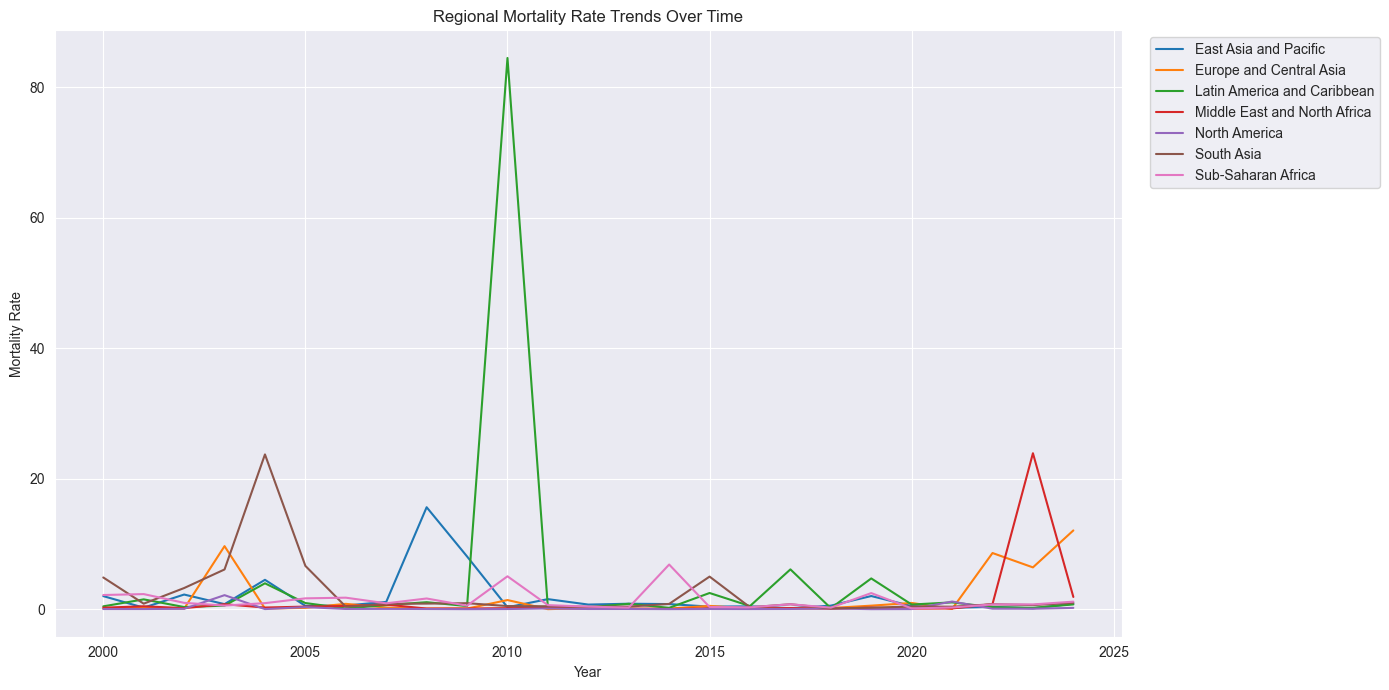

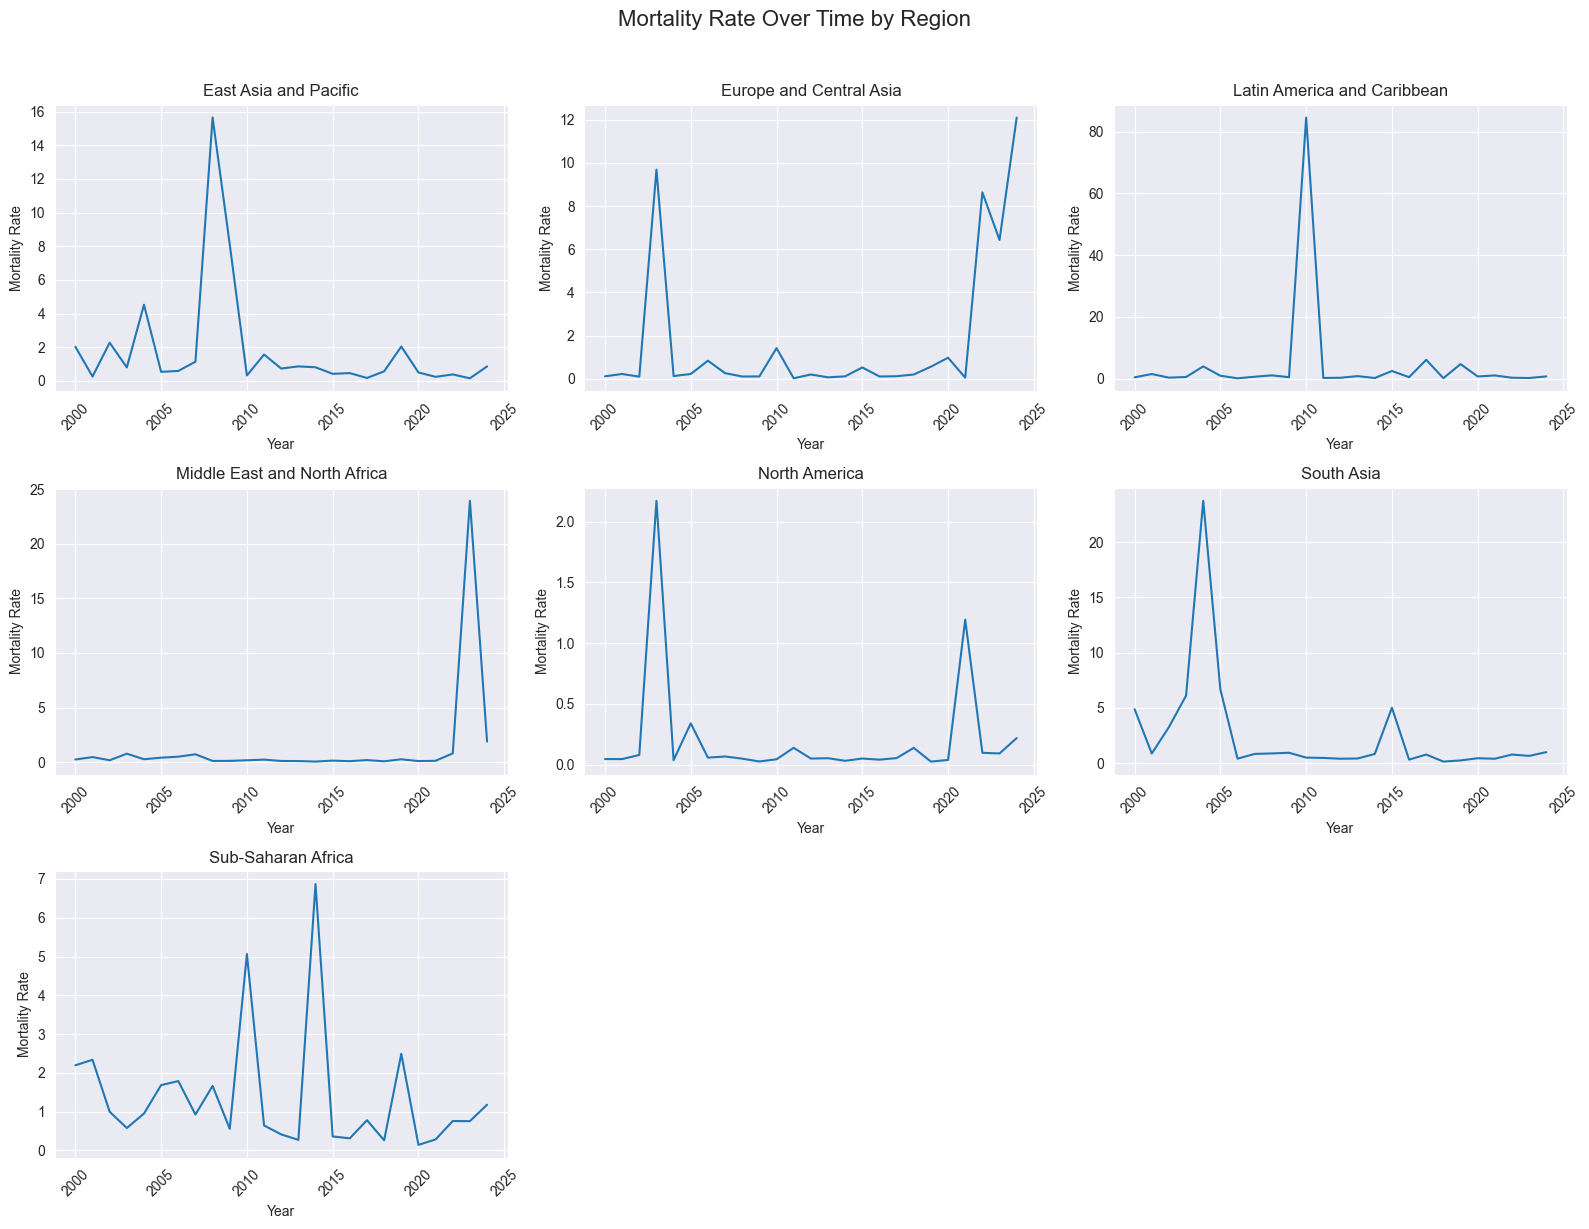

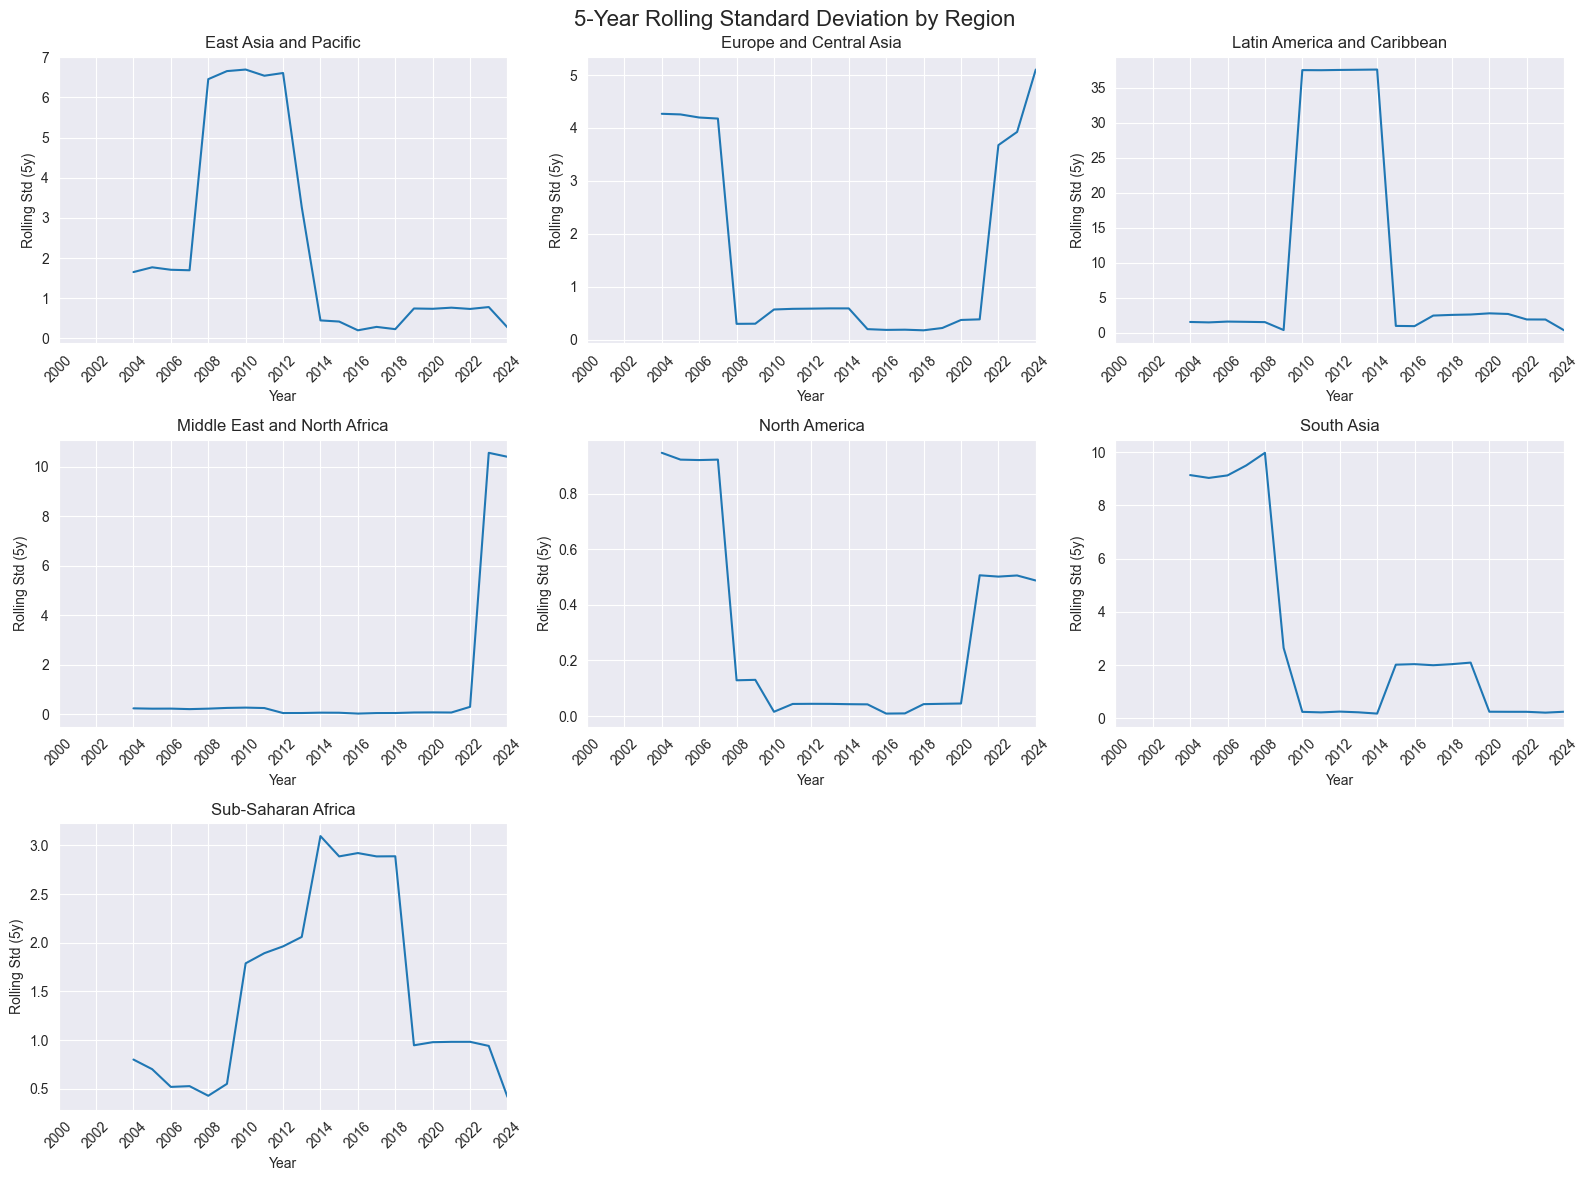

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Prep
region_trend = (
    df.groupby(["Year", "Region"])["Mortality_Rate"]
    .mean()
    .reset_index()
)

regions = sorted(df["Region"].dropna().unique())

# 4.2.1 Comparative
plt.figure(figsize=(14, 7))
sns.lineplot(data=region_trend, x="Year", y="Mortality_Rate", hue="Region")
plt.title("Regional Mortality Rate Trends Over Time")
plt.xlabel("Year")
plt.ylabel("Mortality Rate")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

# 4.2.2 Individual Region Trend

n = len(regions)
ncols = 3
nrows = int(np.ceil(n / ncols))

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(16, 4 * nrows), sharex=True)
axes = np.array(axes).reshape(-1)

for i, region in enumerate(regions):
    ts = (
        df[df["Region"] == region]
        .groupby("Year")["Mortality_Rate"]
        .mean()
        .sort_index()
    )
    ax = axes[i]
    ax.plot(ts.index, ts.values)
    ax.set_title(f"{region}")
    ax.set_xlabel("Year")
    ax.set_ylabel("Mortality Rate")

    # ép hiển thị tick x cho tất cả subplot
    ax.tick_params(axis="x", labelbottom=True, labelrotation=45)

# tắt ô dư
for j in range(i + 1, len(axes)):
    axes[j].axis("off")

fig.suptitle("Mortality Rate Over Time by Region", y=1.02, fontsize=16)
fig.tight_layout()
plt.show()

# 4.2.3 Rolling Volatility (Improved X-axis formatting)

window = 5

years = sorted(df["Year"].unique())
xmin, xmax = min(years), max(years)

fig, axes = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(16, 4 * nrows)
)

axes = np.array(axes).reshape(-1)

for i, region in enumerate(regions):
    ts = (
        df[df["Region"] == region]
        .groupby("Year")["Mortality_Rate"]
        .mean()
        .sort_index()
    )

    rolling_std = ts.rolling(window=window).std()

    ax = axes[i]
    ax.plot(rolling_std.index, rolling_std.values)

    ax.set_title(region)
    ax.set_xlim(xmin, xmax)

    # Tick mỗi 2 năm
    ax.set_xticks(range(xmin, xmax + 1, 2))
    ax.tick_params(axis='x', rotation=45)

    ax.set_xlabel("Year")
    ax.set_ylabel(f"Rolling Std ({window}y)")

# Tắt subplot thừa
for j in range(i + 1, len(axes)):
    axes[j].axis("off")

fig.suptitle(f"{window}-Year Rolling Standard Deviation by Region", fontsize=16)
plt.tight_layout()
plt.show()


In [21]:
# 4.2.4 ADF Summary Table

rows = []
alpha = 0.05

for region in regions:
    ts = (
        df[df["Region"] == region]
        .groupby("Year")["Mortality_Rate"]
        .mean()
        .sort_index()
        .dropna()
    )

    n_years = int(ts.shape[0])

    # Guard: chuỗi quá ngắn
    if n_years < 8:
        rows.append([region, np.nan, "N/A (too short)", np.nan, n_years, np.nan])
        continue

    # Guard: chuỗi hằng
    if np.isclose(ts.max(), ts.min()):
        rows.append([region, np.nan, "N/A (constant)", float(ts.std()), n_years, float(ts.mean())])
        continue

    pval = adfuller(ts, autolag="AIC")[1]
    stationary = "Dừng" if pval < alpha else "Không dừng"

    rows.append([
        region,
        float(pval),
        stationary,
        float(ts.std()),
        n_years,
        float(ts.mean())
    ])

region_adf_summary = pd.DataFrame(
    rows,
    columns=["Region", "ADF_pvalue", "Kết luận", "StdDev", "NumYears", "Mean"]
).sort_values("ADF_pvalue")

# Format p-value cho dễ đọc
region_adf_summary["ADF_pvalue"] = region_adf_summary["ADF_pvalue"].apply(
    lambda x: f"{x:.6f}" if pd.notnull(x) else x
)

region_adf_summary

,Region,ADF_pvalue,Kết luận,StdDev,NumYears,Mean
6,Sub-Saharan Africa,0.000000,Dừng,1.565515,25,1.367546
4,North America,0.000009,Dừng,0.470760,25,0.207854
2,Latin America and Caribbean,0.000021,Dừng,16.733449,25,4.541406
3,Middle East and North Africa,0.000222,Dừng,4.733307,25,1.288127
0,East Asia and Pacific,0.010008,Dừng,3.349188,25,1.836172
5,South Asia,0.018813,Dừng,4.849688,25,2.438883
1,Europe and Central Asia,0.887576,Không dừng,3.448301,25,1.734035


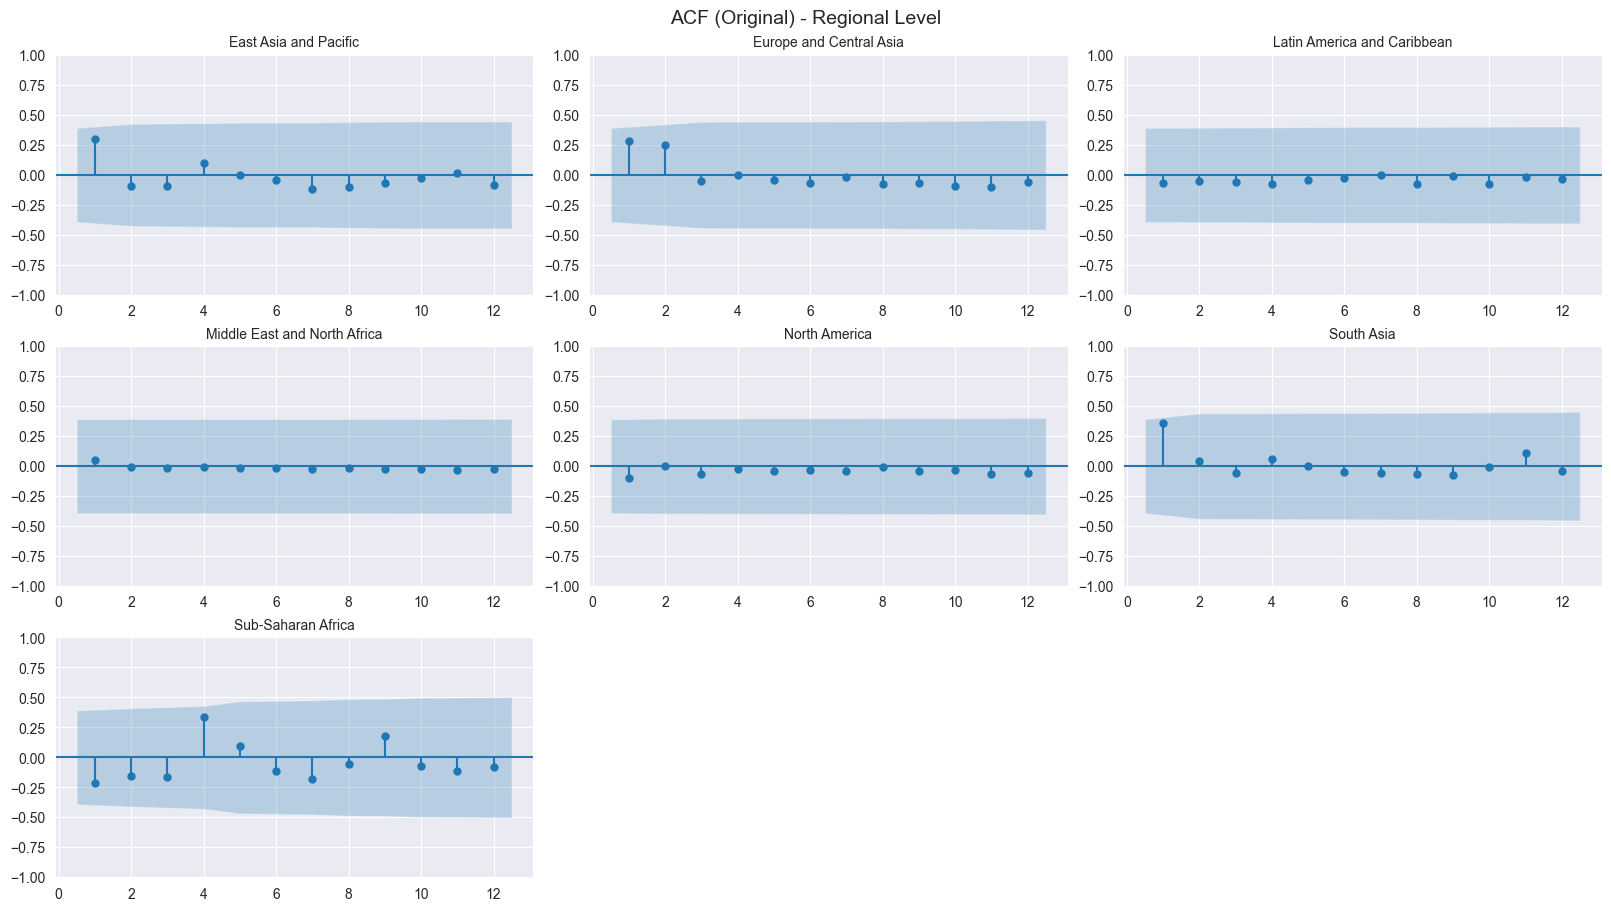

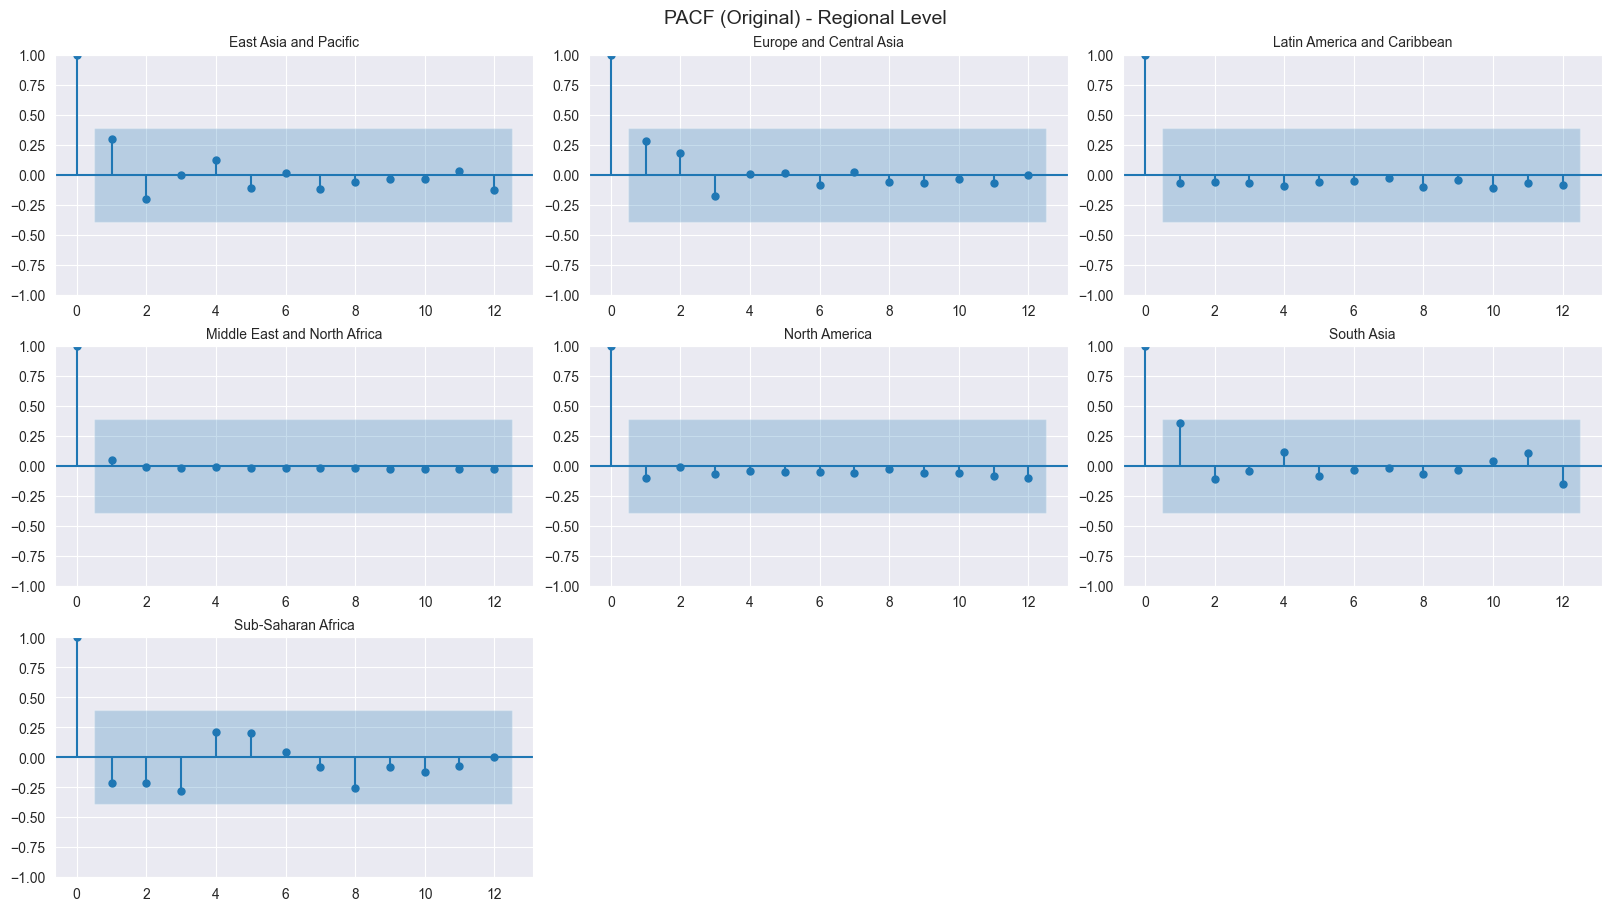

In [8]:
# # 4.2.5 ACF & PACF
#
# def _get_rSegion_ts(region: str):
#     return (
#         df[df["Region"] == region]
#         .groupby("Year")["Mortality_Rate"]
#         .mean()
#         .sort_index()
#         .dropna()
#     )
#
# def plot_grid_acf_pacf_regions(kind="acf", nlags=12, ncols=3, figsize=(16, 9)):
#     n = len(regions)
#     nrows = (n + ncols - 1) // ncols
#
#     fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=figsize, constrained_layout=True)
#     axes = np.array(axes).reshape(-1)
#
#     for i, region in enumerate(regions):
#         ax = axes[i]
#         ts = _get_region_ts(region)
#
#         # guard: too short / constant
#         if ts.shape[0] < 8 or np.isclose(ts.max(), ts.min()):
#             ax.text(0.5, 0.5, "N/A", ha="center", va="center")
#             ax.set_title(region, fontsize=10)
#             ax.axis("off")
#             continue
#
#         if kind == "acf":
#             plot_acf(ts, ax=ax, lags=nlags, zero=False)
#         else:
#             plot_pacf(ts, ax=ax, lags=nlags, method="ywm")
#
#         ax.set_title(region, fontsize=10)
#
#     # tắt ô dư
#     for j in range(i + 1, len(axes)):
#         axes[j].axis("off")
#
#     fig.suptitle(f"{kind.upper()} (Original) - Regional Level", fontsize=14)
#     plt.show()
#     plt.close()
#
# plot_grid_acf_pacf_regions(kind="acf",  nlags=12, ncols=3, figsize=(16, 9))
# plot_grid_acf_pacf_regions(kind="pacf", nlags=12, ncols=3, figsize=(16, 9))

# 4.3 SELECTED COUNTRY-LEVEL ANALYSIS

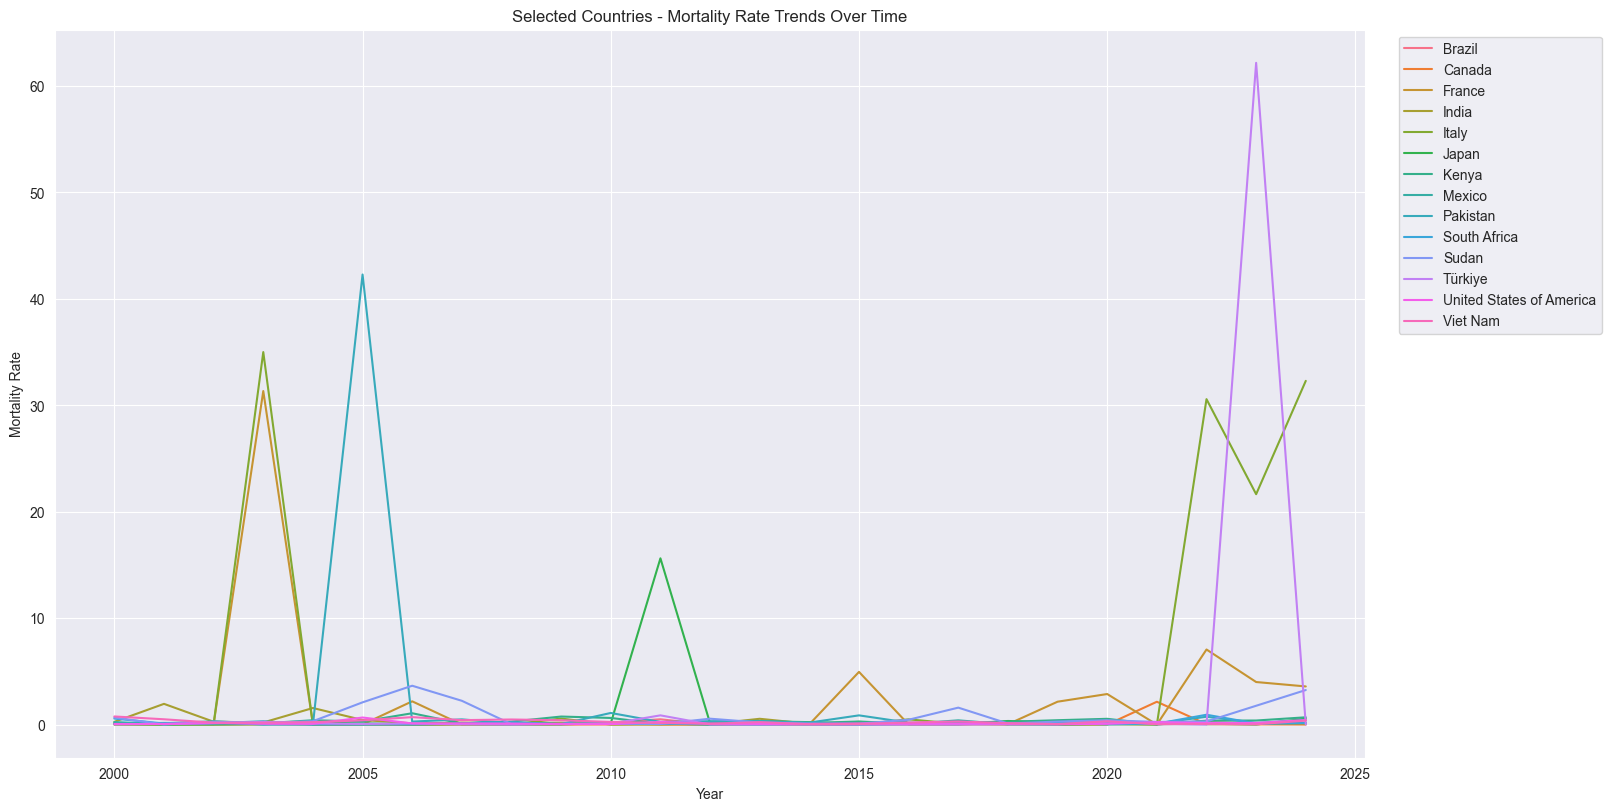

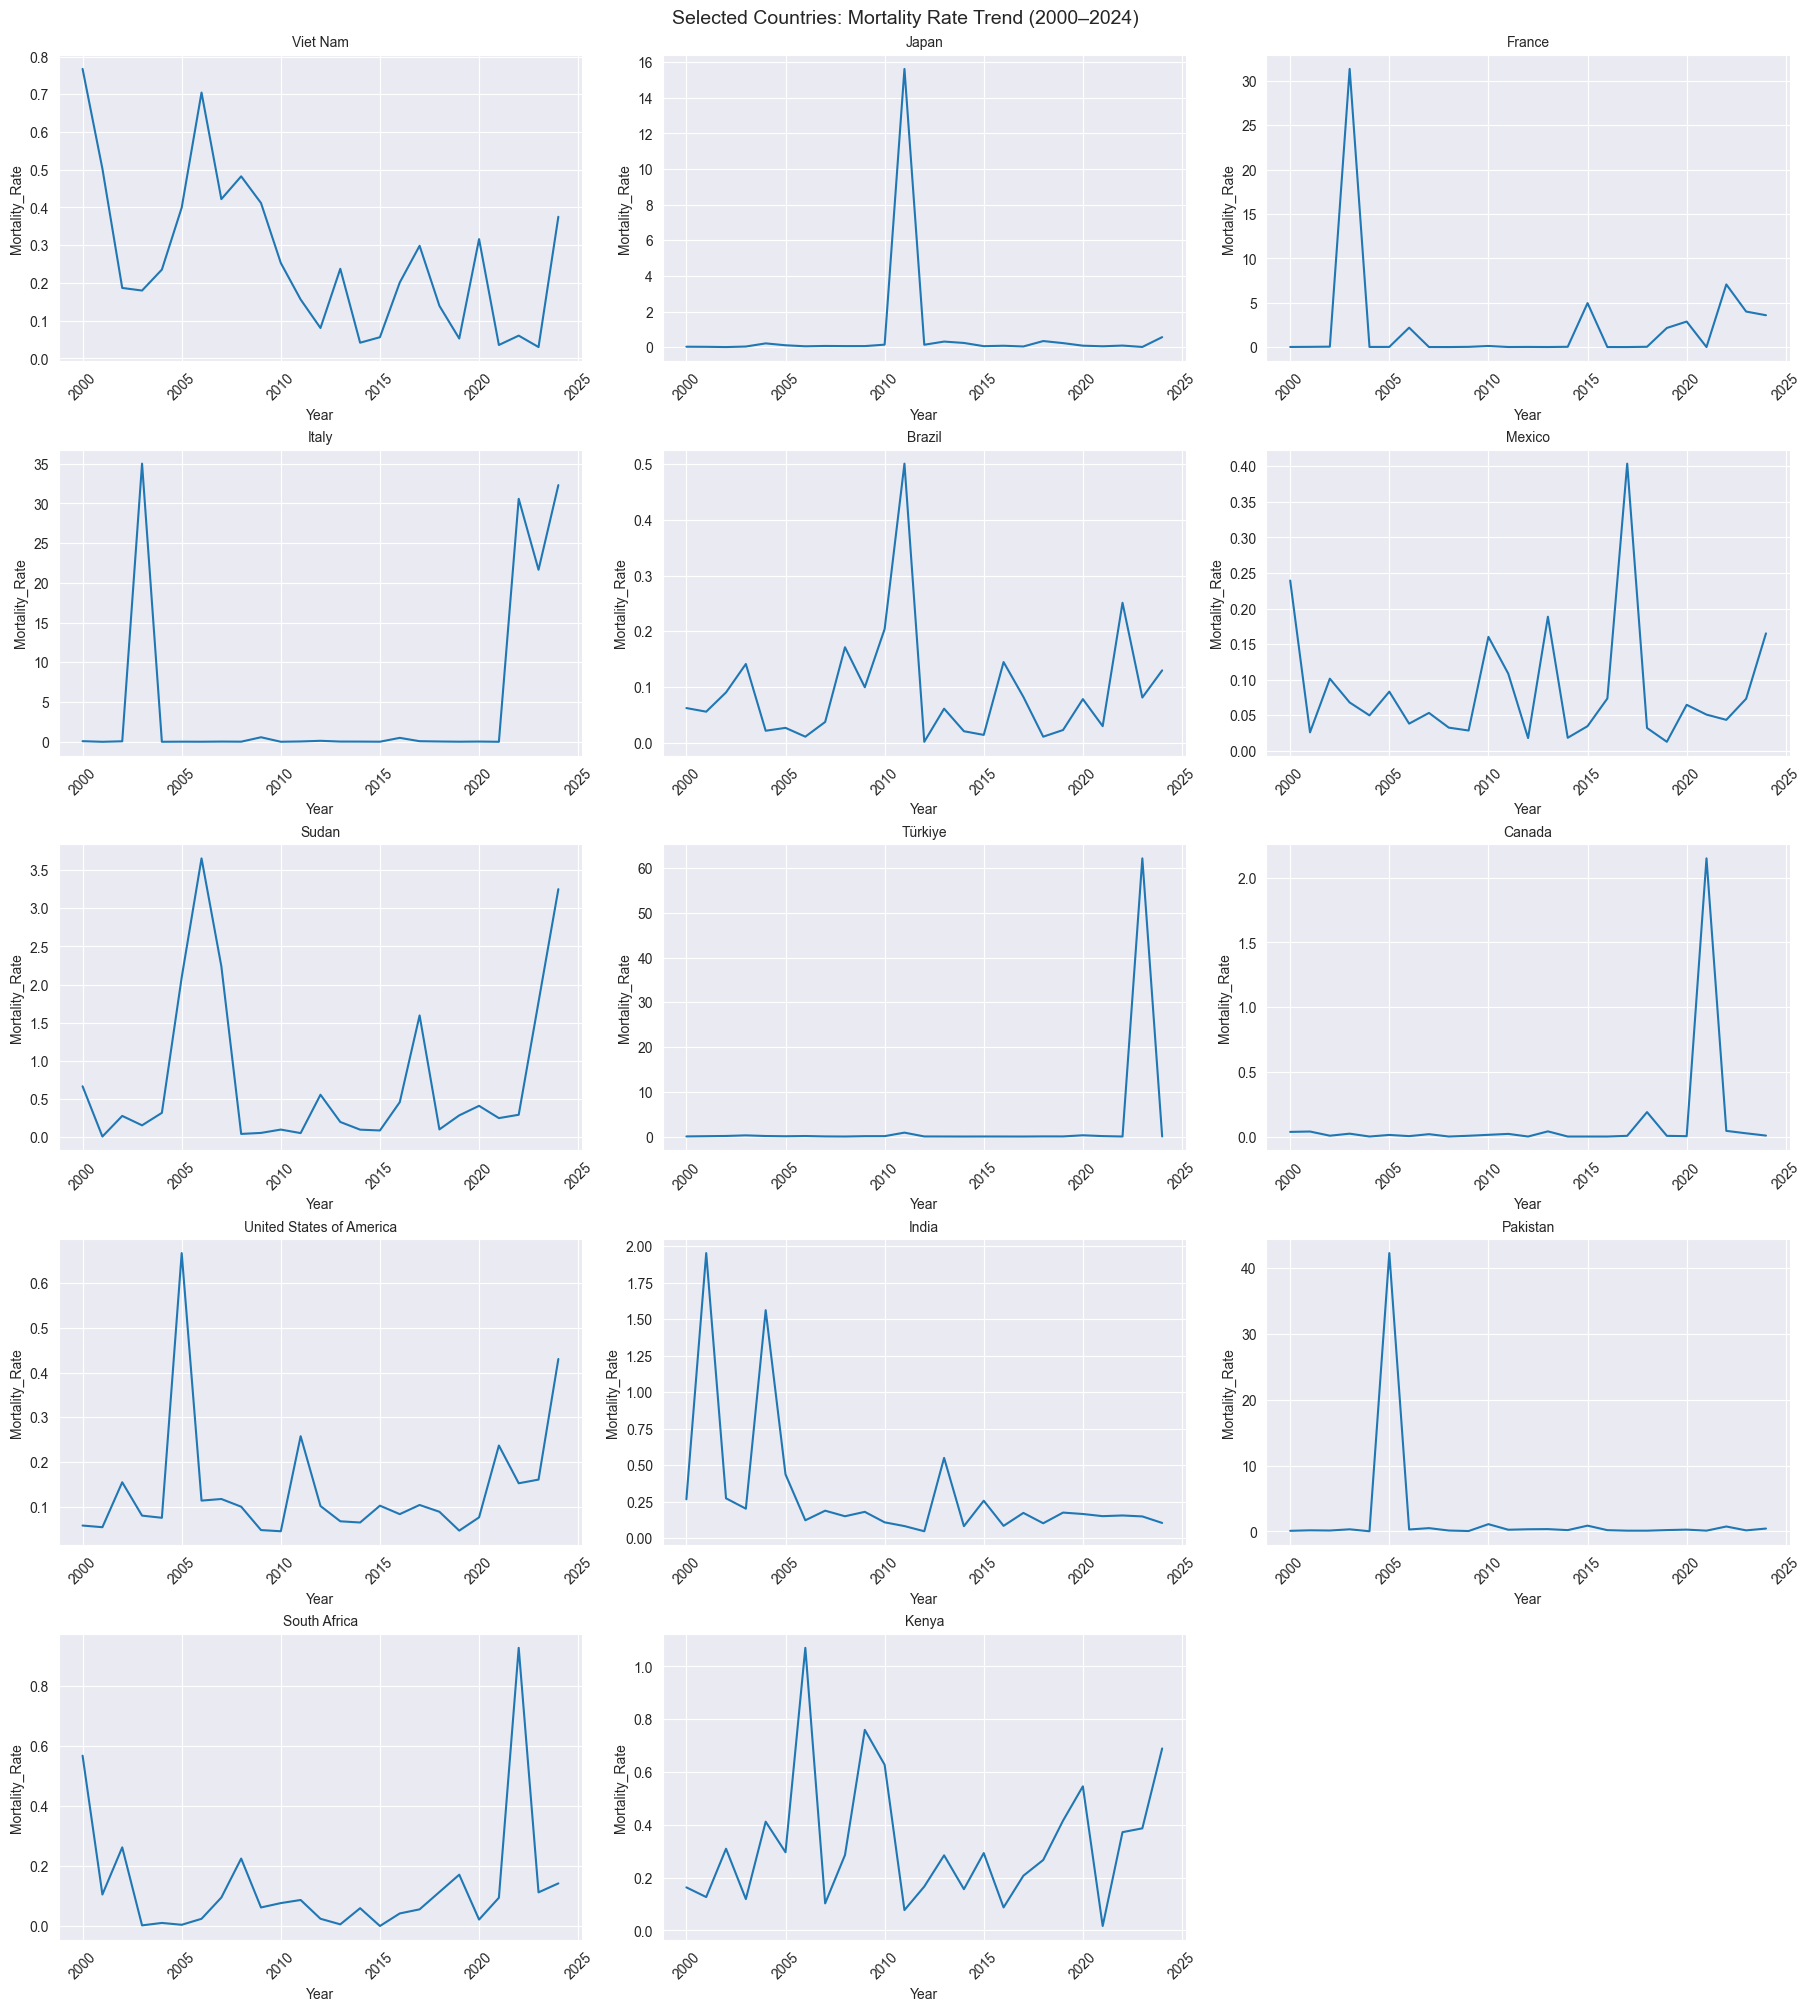

In [22]:
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# 4.3.1 Define Selected Countries
selected_countries = [
    "Viet Nam", "Japan",
    "France", "Italy",
    "Brazil", "Mexico",
    "Sudan", "Türkiye",
    "Canada", "United States of America",
    "India", "Pakistan",
    "South Africa", "Kenya"
]

country_df = df[df["Country"].isin(selected_countries)].copy()

# 4.3.2 Country Trend Comparison (All Selected Countries) - (giữ nếu bạn muốn)
plt.figure(figsize=(16,8), constrained_layout=True)
sns.lineplot(data=country_df, x="Year", y="Mortality_Rate", hue="Country")
plt.title("Selected Countries - Mortality Rate Trends Over Time")
plt.xlabel("Year")
plt.ylabel("Mortality Rate")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.show()
plt.close()

# Prepare grouped series
plot_df = (
    df[df["Country"].isin(selected_countries)]
    .groupby(["Country", "Year"])["Mortality_Rate"]
    .mean()
    .reset_index()
    .sort_values(["Country", "Year"])
)

countries = selected_countries
n = len(countries)

# 4.3.3 Trend ONLY (1 figure)
countries = selected_countries
n = len(countries)

ncols = 3
nrows = int(np.ceil(n / ncols))

fig, axes = plt.subplots(
    nrows=nrows, ncols=ncols,
    figsize=(18, 4.0 * nrows),
    sharex=True,
    constrained_layout=True
)

axes = np.array(axes).reshape(-1)

for i, c in enumerate(countries):
    ts = plot_df[plot_df["Country"] == c].sort_values("Year")
    ax = axes[i]
    ax.plot(ts["Year"], ts["Mortality_Rate"])
    ax.set_title(c, fontsize=10)

    ax.set_ylabel("Mortality_Rate")
    ax.set_xlabel("Year")

    # ép hiển thị tick x cho tất cả subplot
    ax.tick_params(axis="x", labelbottom=True, labelrotation=45)

# tắt subplot dư
for j in range(i + 1, len(axes)):
    axes[j].axis("off")

fig.suptitle("Selected Countries: Mortality Rate Trend (2000–2024)", fontsize=14)
plt.show()
plt.close()

# # =========================
# # 4.3.4 Volatility ONLY (1 figure)
# # =========================
# fig, axes = plt.subplots(
#     nrows=n, ncols=1,
#     figsize=(18, 2.0 * n),
#     constrained_layout=True
# )
#
# for i, c in enumerate(countries):
#     ts = plot_df[plot_df["Country"] == c].sort_values("Year").copy()
#     ts["roll_std_5y"] = ts["Mortality_Rate"].rolling(5).std()
#
#     axes[i].plot(ts["Year"], ts["roll_std_5y"])
#     axes[i].set_title(f"{c} - 5Y Rolling Std", fontsize=10)
#     axes[i].set_xlabel("Year")
#     axes[i].set_ylabel("Rolling Std (5Y)")
#     axes[i].tick_params(axis="x", labelrotation=45)
#
# fig.suptitle("Selected Countries: 5-Year Rolling Volatility", fontsize=14)
# plt.show()
# plt.close()

In [23]:
# 4.3.5 Stationarity (ADF) Summary Table

alpha = 0.05  # mức ý nghĩa

rows = []
for country in selected_countries:
    ts = (
        country_df[country_df["Country"] == country]
        .groupby("Year")["Mortality_Rate"]
        .mean()
        .sort_index()
        .dropna()
    )

    # ADF needs enough points + non-constant series
    if ts.shape[0] < 3 or np.isclose(ts.max(), ts.min()):
        pval = np.nan
        conclusion = "Không đủ dữ liệu"
    else:
        try:
            pval = adfuller(ts)[1]
            conclusion = "Dừng" if pval < alpha else "Không dừng"
        except Exception:
            pval = np.nan
            conclusion = "Không đủ dữ liệu"

    rows.append([
        country,
        pval,
        conclusion,
        float(ts.std()) if ts.shape[0] else np.nan,
        int(ts.shape[0]),
        float(ts.mean()) if ts.shape[0] else np.nan
    ])
country_adf_summary = (
    pd.DataFrame(
        rows,
        columns=["Country", "ADF_pvalue", "Kết luận", "StdDev", "NumYears", "Mean"]
    )
    .sort_values(["Kết luận", "StdDev"], ascending=[True, False])
)

# Format p-value cho đẹp (6 chữ số)
country_adf_summary["ADF_pvalue"] = country_adf_summary["ADF_pvalue"].apply(
    lambda x: f"{x:.6f}" if pd.notna(x) else x
)

country_adf_summary

,Country,ADF_pvalue,Kết luận,StdDev,NumYears,Mean
2,France,0.000013,Dừng,6.344719,25,2.343288
1,Japan,0.000036,Dừng,3.102961,25,0.745417
12,South Africa,0.000021,Dừng,0.208701,24,0.132386
0,Viet Nam,0.011486,Dừng,0.204071,25,0.264969
4,Brazil,0.000353,Dừng,0.107050,25,0.093863
5,Mexico,0.000000,Dừng,0.088029,25,0.086717
7,Türkiye,0.997081,Không dừng,12.945027,23,2.804553
3,Italy,0.649136,Không dừng,11.338524,25,4.848543
11,Pakistan,0.258007,Không dừng,8.403840,25,1.973932
6,Sudan,0.257498,Không dừng,1.044281,24,0.720642


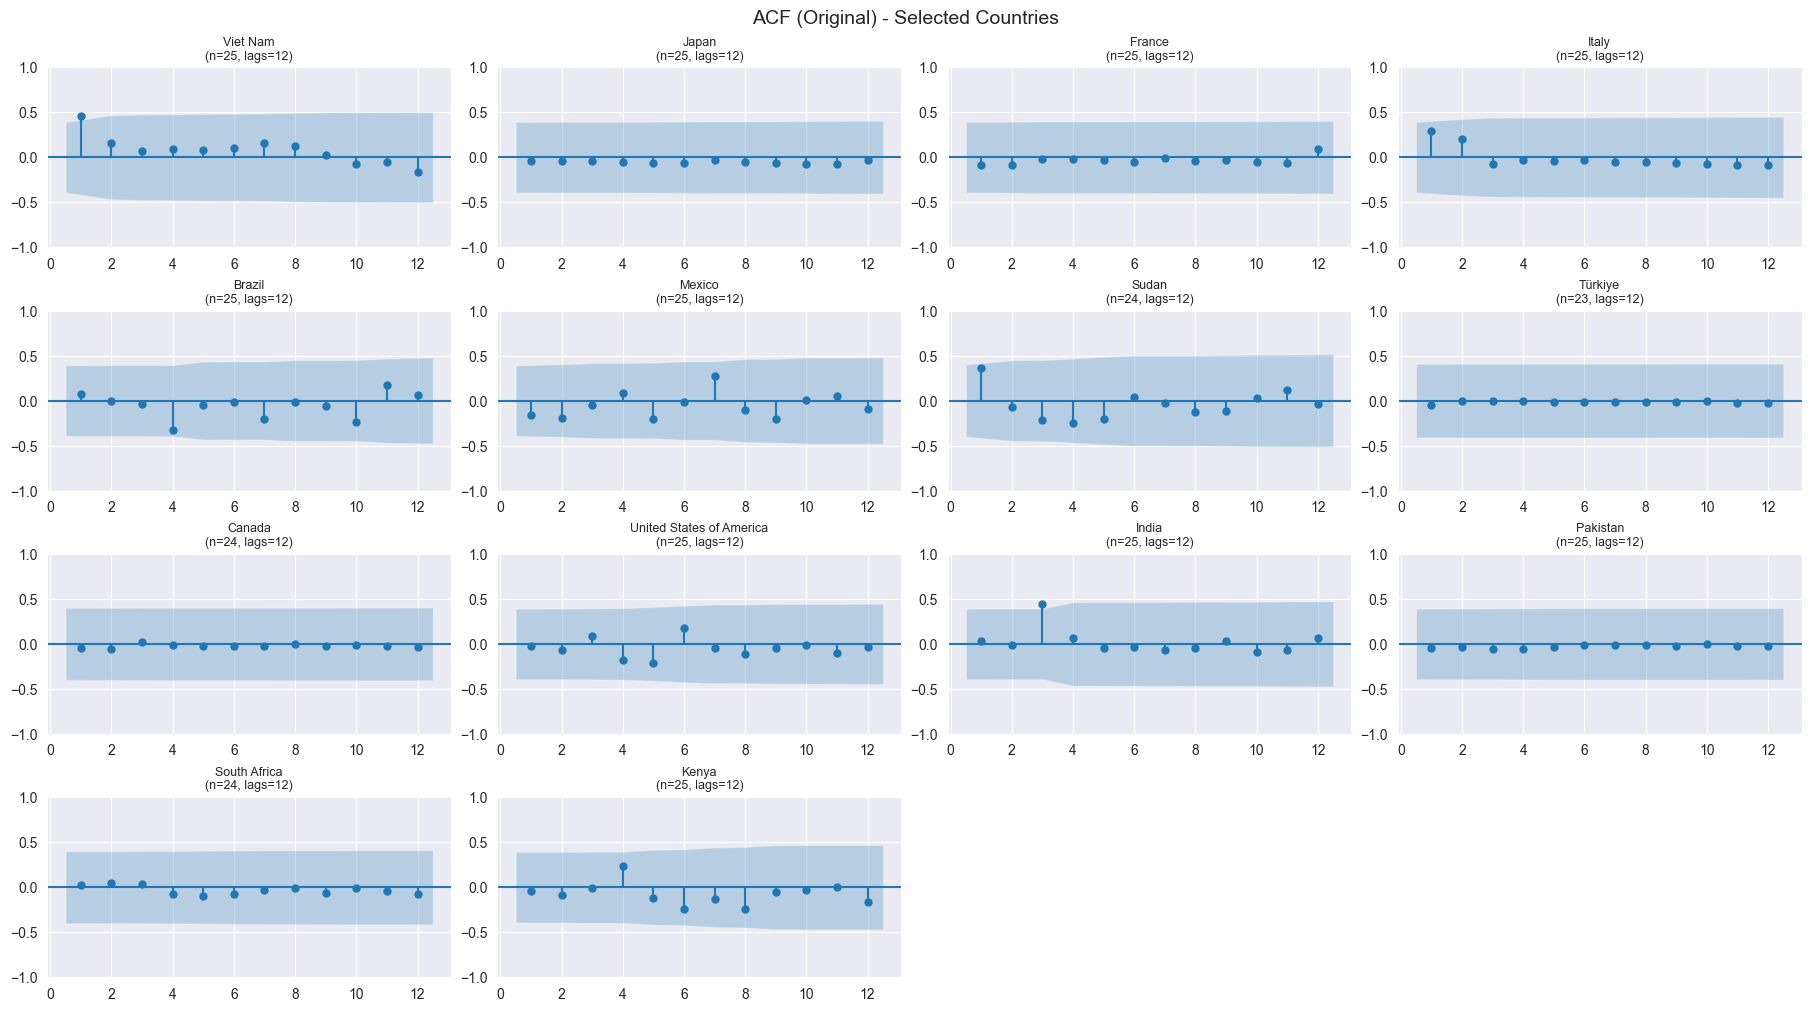

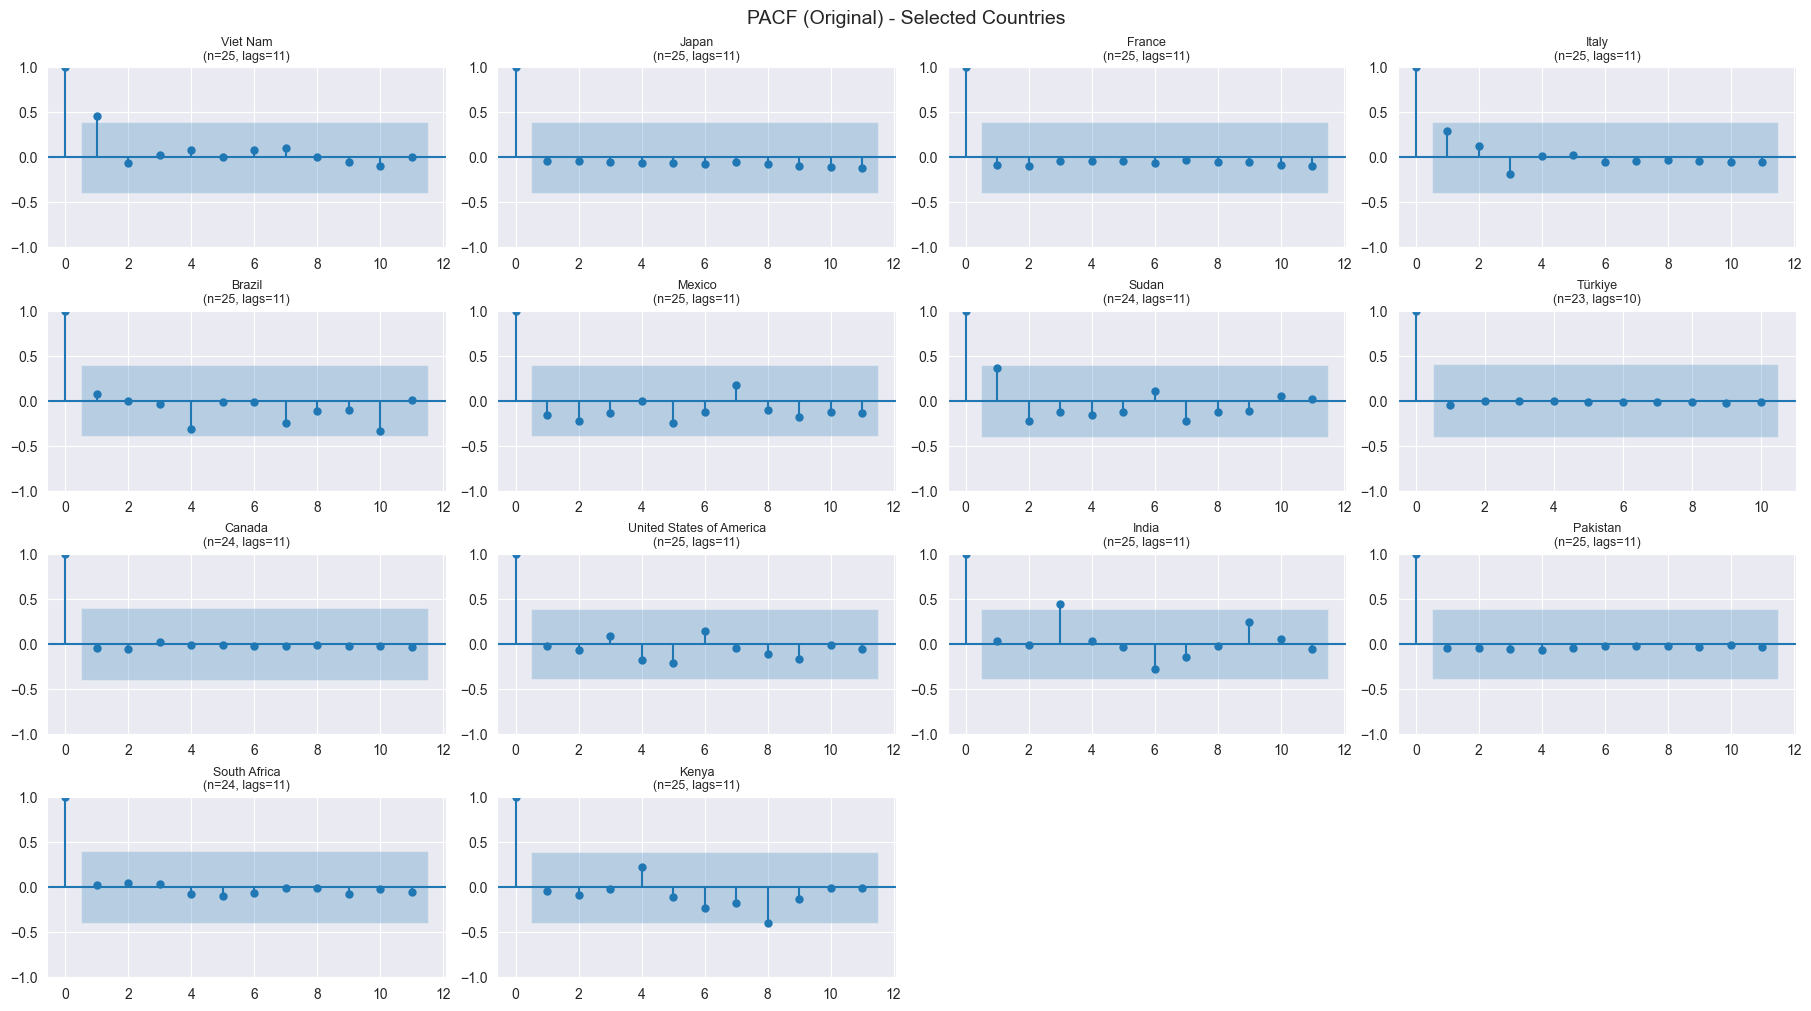

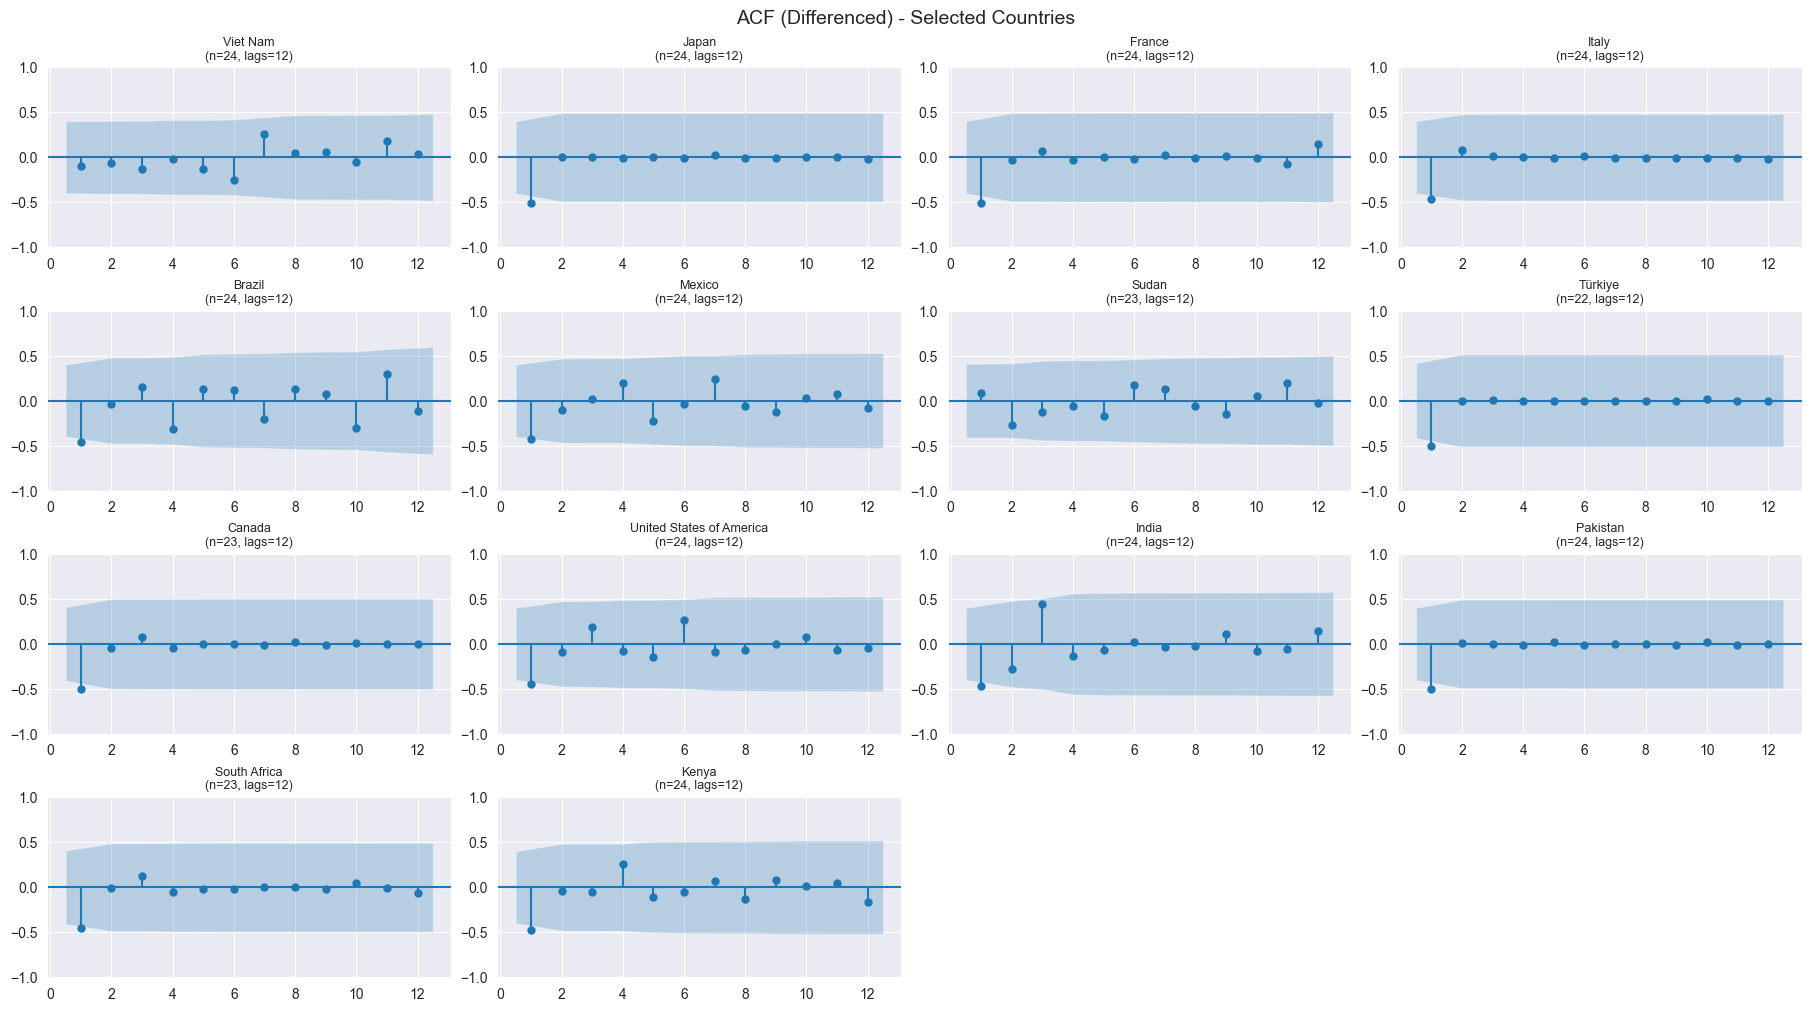

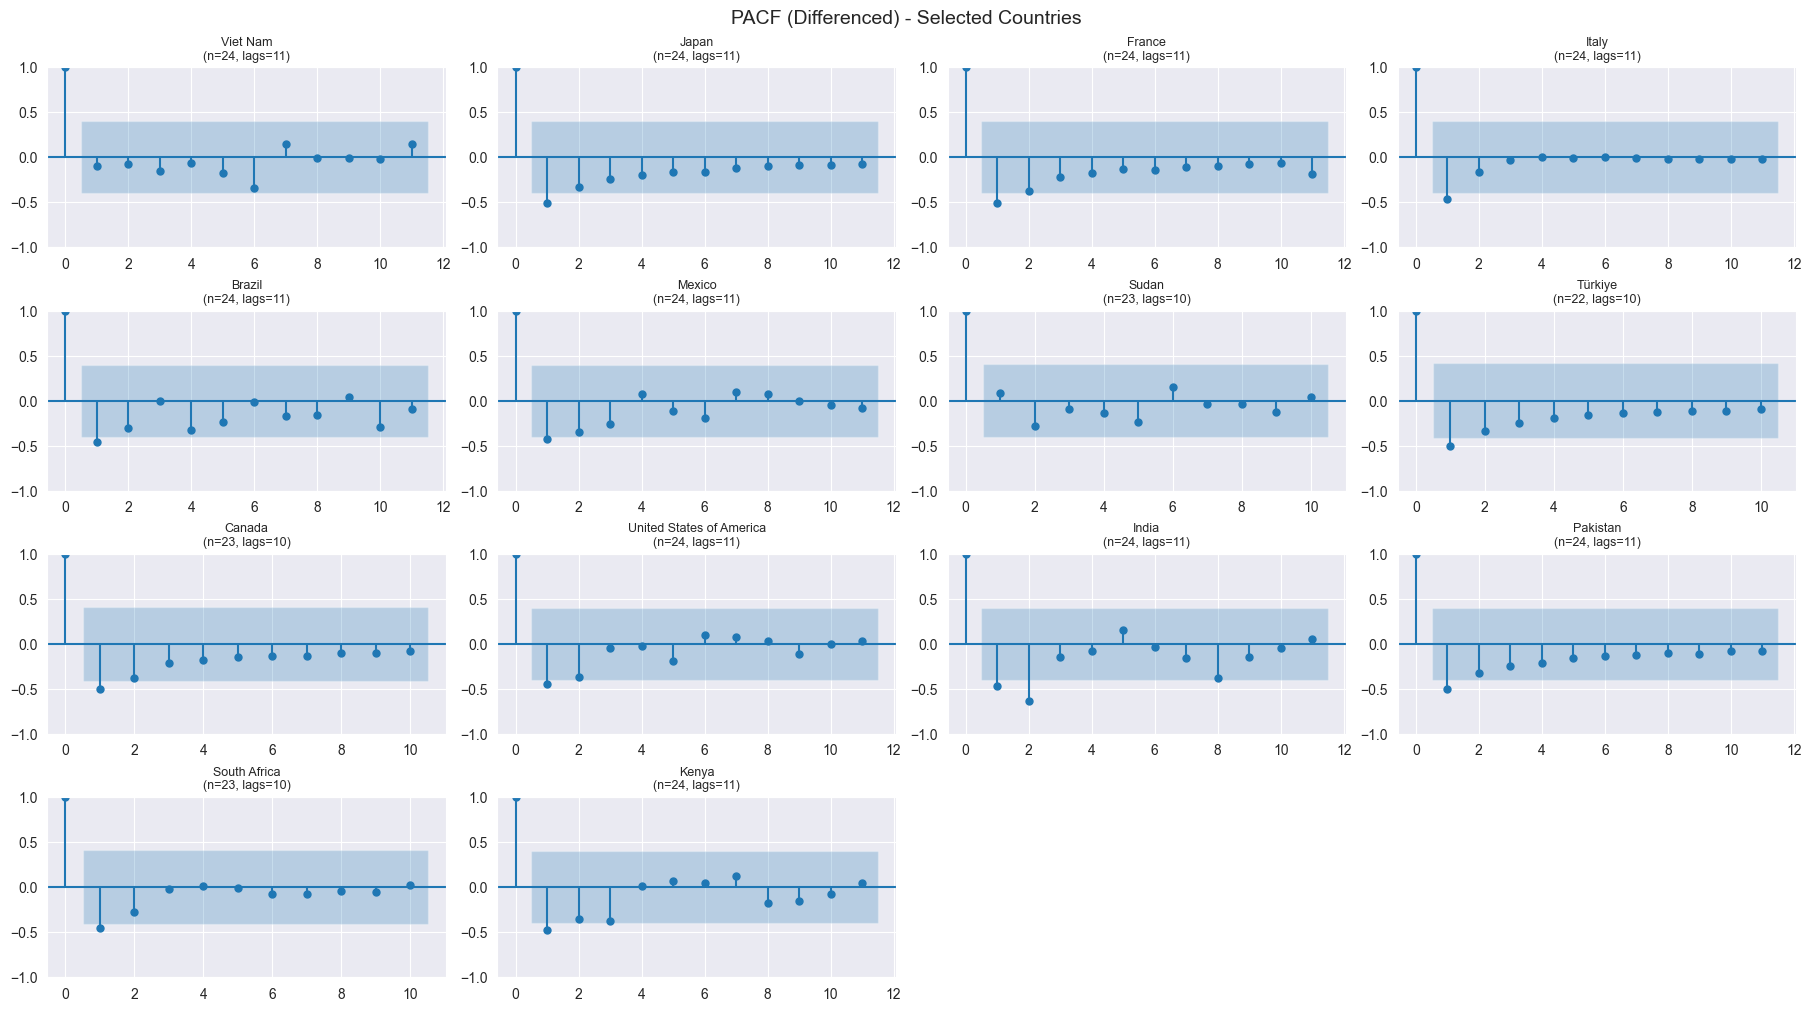

In [24]:
# 4.3.6 ACF & PACF (Selected Countries)

def _get_country_ts(country: str):
    return (
        country_df[country_df["Country"] == country]
        .groupby("Year")["Mortality_Rate"]
        .mean()
        .sort_index()
        .dropna()
    )

def plot_grid_acf_pacf(kind="acf", series="original", nlags=12, ncols=4, figsize=(18, 10)):
    countries = selected_countries
    n = len(countries)
    nrows = (n + ncols - 1) // ncols

    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=figsize, constrained_layout=True)
    axes = np.array(axes).reshape(-1)

    for i, country in enumerate(countries):
        ax = axes[i]
        ts = _get_country_ts(country)

        if series == "diff":
            ts = ts.diff().dropna()

        nobs = ts.shape[0]

        if nobs == 0:
            ax.text(0.5, 0.5, "EMPTY", ha="center", va="center")
            ax.set_title(country, fontsize=9)
            ax.axis("off")
            continue

        if nobs < 8 or np.isclose(ts.max(), ts.min()):
            ax.text(0.5, 0.5, "N/A", ha="center", va="center")
            ax.set_title(country, fontsize=9)
            ax.axis("off")
            continue

        # clamp nlags to avoid statsmodels PACF constraint: nlags < nobs/2
        max_lags = (nobs // 2) - 1 if kind == "pacf" else (nobs - 1)
        if max_lags < 1:
            ax.text(0.5, 0.5, "N/A", ha="center", va="center")
            ax.set_title(country, fontsize=9)
            ax.axis("off")
            continue

        nlags_use = min(nlags, int(max_lags))

        if kind == "acf":
            plot_acf(ts, ax=ax, lags=nlags_use, zero=False)
        else:
            plot_pacf(ts, ax=ax, lags=nlags_use, method="ywm")

        ax.set_title(f"{country}\n(n={nobs}, lags={nlags_use})", fontsize=9)

    for j in range(i + 1, len(axes)):
        axes[j].axis("off")

    fig.suptitle(
        f"{kind.upper()} ({'Original' if series=='original' else 'Differenced'}) - Selected Countries",
        fontsize=14
    )
    plt.show()
    plt.close(fig)

# Original
plot_grid_acf_pacf(kind="acf",  series="original", nlags=12)
plot_grid_acf_pacf(kind="pacf", series="original", nlags=12)

# Differenced
plot_grid_acf_pacf(kind="acf",  series="diff", nlags=12)
plot_grid_acf_pacf(kind="pacf", series="diff", nlags=12)